<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
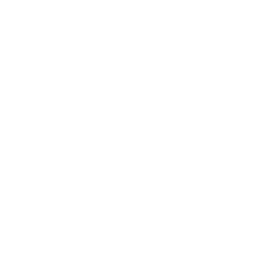
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">選挙区投票パターン分析</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 政府・選挙統計 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

この分析では、100地区からなる模擬の郡選挙データセットにおいて、政党支持が地区タイプ（都市部・郊外・農村部）にわたって体系的に変化するかどうかを検証する。政党×タイプの多くのセルが疎であるため——最小の分割表セルはわずか1～2地区しか保持せず、期待度数は5未満である——一般連関の包括的なピアソンのカイ二乗検定はここでは検出力不足で信頼性に欠ける。そこで本分析はこれを**コクラン・アーミテージ傾向検定**で補完する。これは都市部から農村部への自然な順序性を利用し、「政党Aの支持はその勾配に沿って単調に減少するか」というより鋭い問いを立てる、焦点を絞った単一自由度の検定である。傾向検定は正確なp値を報告し、これはセル数が小さい場合に適切な推測手法である。2つの検定の対比こそがこの例の分析上のポイントである：一般的な連関検定は、順序づけられた傾向検定が検出する実際の方向性のあるパターンを見逃すことがある。


## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | 地区レベルのレコード。地区ごとに1行、地区タイプ・郡・最多得票政党を含む | 100 |

このランタイムはライセンスなしモードで実行され、出力は100観測に制限される；本分析はこの地区レベルのサンプルを前提に設計されており、分割表セルが実際に小さく、正確傾向検定が自然な手法となるようにしている。


---

In [1]:
/* --------------------------------------------------------
   Generate synthetic precinct-level voting data
   Small cell counts in rural precincts to demonstrate
   need for exact tests
   -------------------------------------------------------- */
データ work.precinct_votes;
    長さ county_name $30 precinct_type $10 party $12;
    呼出 streaminit(42);
    配列 party_list[4] $15 _temporary_ ('PARTY_A' 'PARTY_B' 'PARTY_C' 'INDEPENDENT');
    配列 type_list[3] $10 _temporary_ ('URBAN' 'SUBURBAN' 'RURAL');
    繰返 precinct_seq = 1 から 500;
        precinct_id = cat('PCT-', PUT(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        もし county_idx = 1 なら county_name = 'ジェファーソン郡';
        他 もし county_idx = 2 なら county_name = 'ハミルトン郡';
        他 もし county_idx = 3 なら county_name = 'マディソン郡';
        他 もし county_idx = 4 なら county_name = 'アダムズ郡';
        他 county_name = 'モンロー郡';
        /* Assign precinct type with weighting */
        type_prob = rand('uniform');
        もし type_prob < 0.30 なら precinct_type = '都市部';
        他 もし type_prob < 0.65 なら precinct_type = '郊外';
        他 precinct_type = '農村部';
        /* Assign party with type-dependent distribution */
        party_prob = rand('uniform');
        もし precinct_type = '都市部' なら 繰返;
            もし party_prob < 0.55 なら party = '政党A';
            他 もし party_prob < 0.80 なら party = '政党B';
            他 もし party_prob < 0.92 なら party = '政党C';
            他 party = '無所属';
        終了;
        他 もし precinct_type = '郊外' なら 繰返;
            もし party_prob < 0.40 なら party = '政党A';
            他 もし party_prob < 0.75 なら party = '政党B';
            他 もし party_prob < 0.88 なら party = '政党C';
            他 party = '無所属';
        終了;
        他 繰返; /* 農村部 - 少数政党のセルは小さい */
            もし party_prob < 0.25 なら party = '政党A';
            他 もし party_prob < 0.70 なら party = '政党B';
            他 もし party_prob < 0.85 なら party = '政党C';
            他 party = '無所属';
        終了;
        /* Vote count varies by precinct type */
        もし precinct_type = '都市部' なら
            vote_count = int(rand('normal', 120, 40));
        他 もし precinct_type = '郊外' なら
            vote_count = int(rand('normal', 80, 25));
        他
            vote_count = int(rand('normal', 25, 12));
        もし vote_count < 1 なら vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        出力;
    終了;
    削除 precinct_seq county_idx type_prob party_prob;
実行;



NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.17 seconds
  cpu   0.17 seconds


---

                                                   The FREQ Procedure

地区タイプ              Frequency    Percent
----------------------------------------
農村部                       34     34.00
郊外                        37     37.00
都市部                       29     29.00

政党           Frequency    Percent
----------------------------------
政党A                 45     45.00
政党B                 34     34.00
政党C                 12     12.00
無所属                  9      9.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


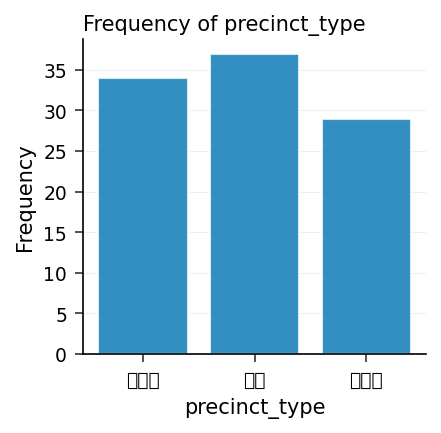

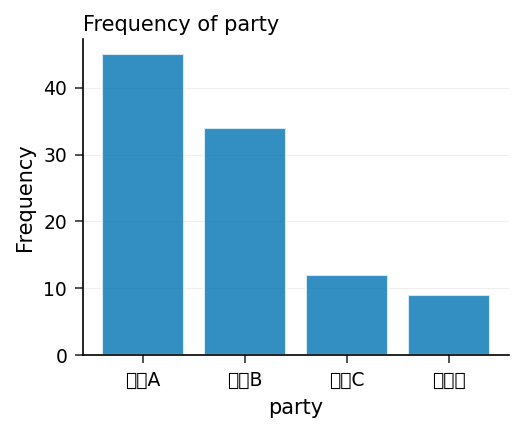

In [2]:
/* --------------------------------------------------------
   Baseline precinct type and party distribution
   -------------------------------------------------------- */
処理 度数 データ=work.precinct_votes;
    TABLES precinct_type / nocum;
    TABLES party / nocum;
    見出 precinct_type = "地区タイプ" party = "政党";
実行;


---


NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


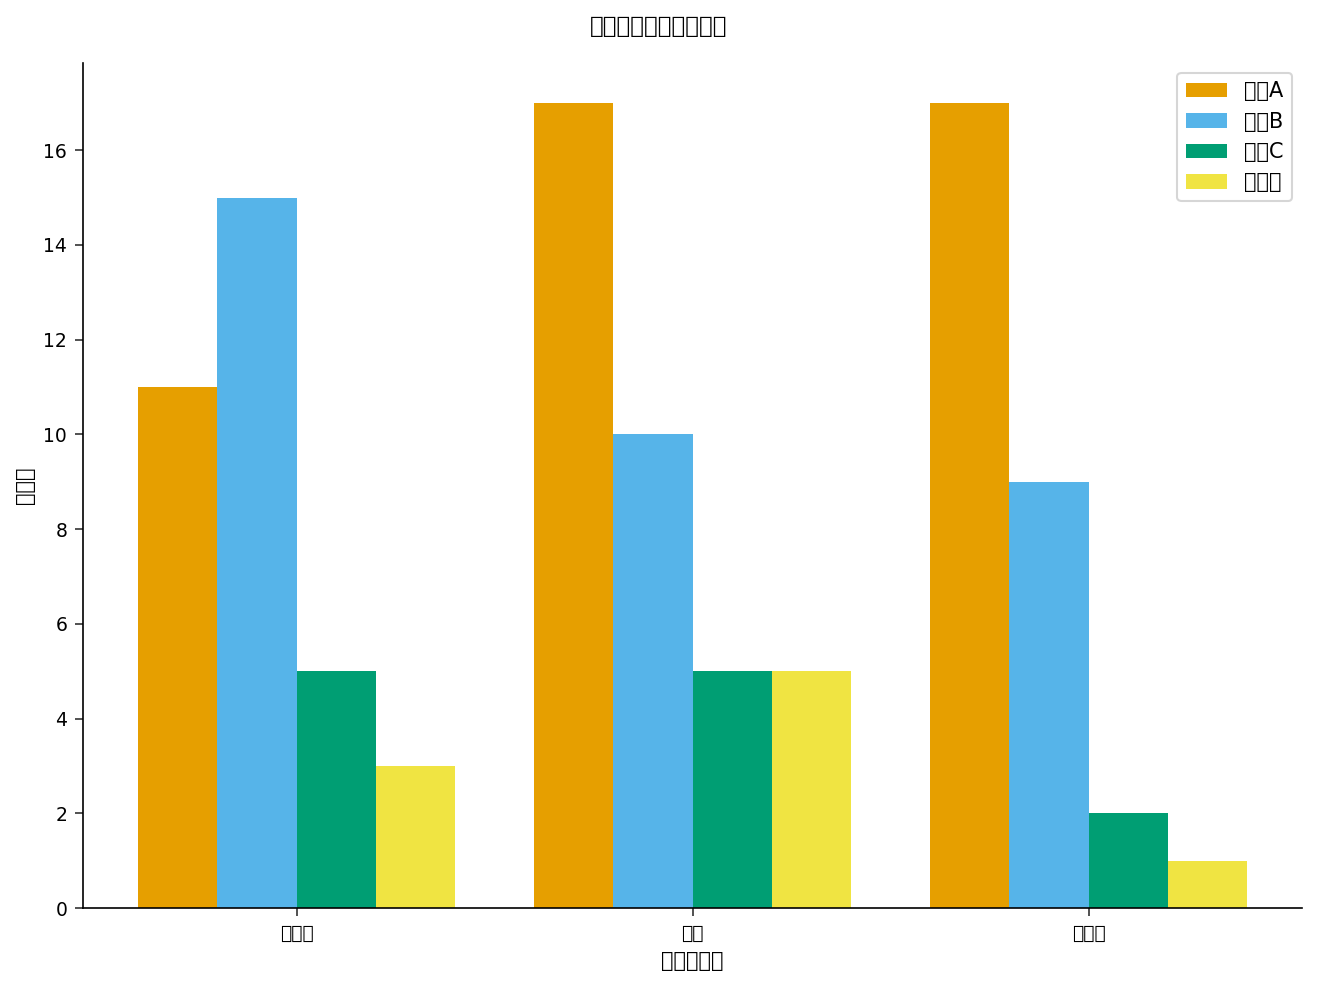

In [3]:
/* --------------------------------------------------------
   Party affiliation by precinct type (precinct counts)
   -------------------------------------------------------- */
処理 SGPLOT データ=work.precinct_votes;
    VBAR precinct_type / GROUP=party GROUPDISPLAY=群
        STAT=度数;
    見出 precinct_type = "地区タイプ" party = "政党";
    XAXIS 見出='地区タイプ';
    YAXIS 見出='地区数';
    表題 '地区タイプ別政党支持';
実行;


---

                                                 地区タイプ×政党：期待度数を伴うクロス集計                                                  

                                                   The FREQ Procedure

Table of 地区タイプ by 政党

地区タイプ           |       政党A |       政党B |       政党C |       無所属 |      Total
----------------+-----------+-----------+-----------+-----------+-----------
農村部             |        11 |        15 |         5 |         3 |         34
                |     11.00 |     15.00 |      5.00 |      3.00 |      34.00
                |     15.30 |     11.56 |      4.08 |      3.06 |           
                |     32.35 |     44.12 |     14.71 |      8.82 |     100.00
                |     24.44 |     44.12 |     41.67 |     33.33 |      34.00
----------------+-----------+-----------+-----------+-----------+-----------
郊外              |        17 |        10 |         5 |         5 |         37
                |     17.00 |     10.00 |      5.00 |      5.00 |      37.00
               


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


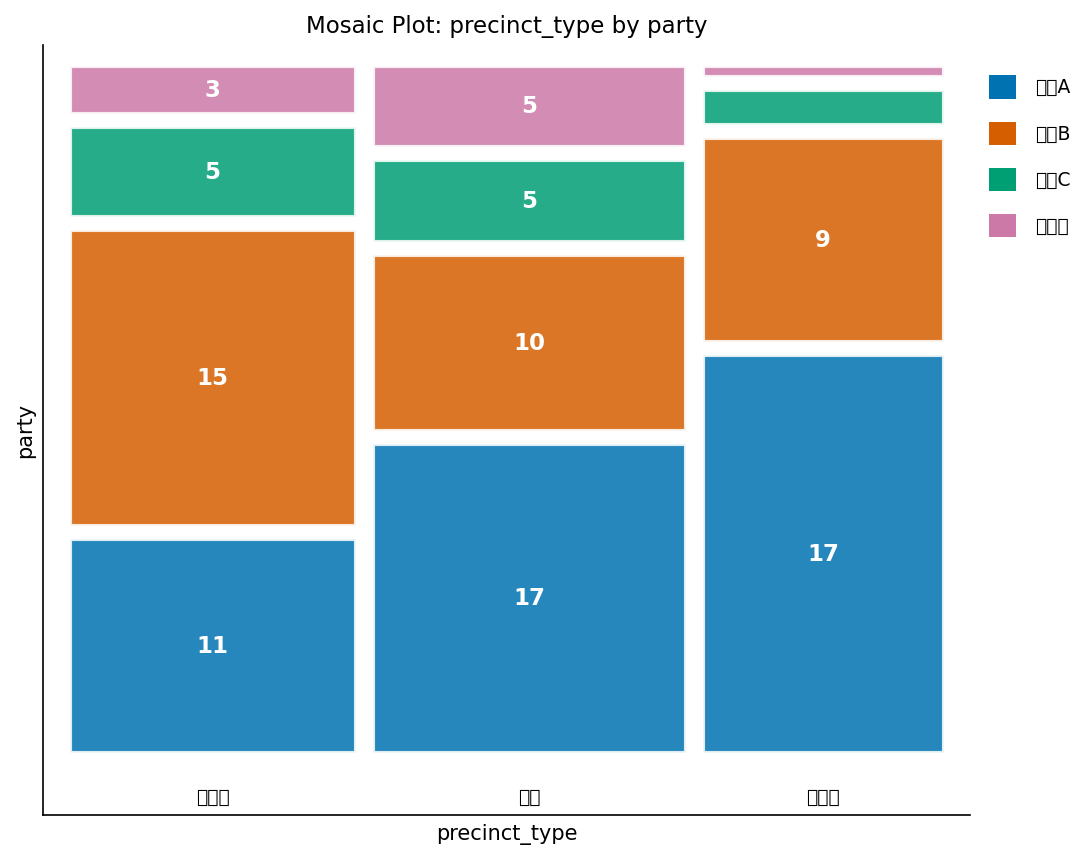

In [4]:
/* --------------------------------------------------------
   Precinct type x party cross-tabulation.
   Request EXPECTED counts so the sparse cells are visible,
   plus the asymptotic Pearson chi-square test of general
   association. Note the small expected counts in the
   INDEPENDENT and PARTY_C columns -- the cue that an
   ordered, exact trend test is the better inferential tool.
   -------------------------------------------------------- */
処理 度数 データ=work.precinct_votes;
    TABLES precinct_type * party / chisq expected;
    見出 precinct_type = "地区タイプ" party = "政党";
    表題 '地区タイプ×政党：期待度数を伴うクロス集計';
実行;


                                             コクラン・アーミテージ傾向検定：地区勾配に沿った政党A支持                                              

                                                   The FREQ Procedure

Table of 地区順序 (1=都市部,2=郊外,3=農村部) by 政党A支持フラグ

地区順序 (1=都市部,2=郊外,3=農村部)                         |         0 |         1 |      Total
------------------------------------------------+-----------+-----------+-----------
1                                               |        12 |        17 |         29
                                                |     12.00 |     17.00 |      29.00
                                                |     41.38 |     58.62 |     100.00
                                                |     21.82 |     37.78 |      29.00
------------------------------------------------+-----------+-----------+-----------
2                                               |        20 |        17 |         37
                                                |     20.00 |     17.00 |      37


NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


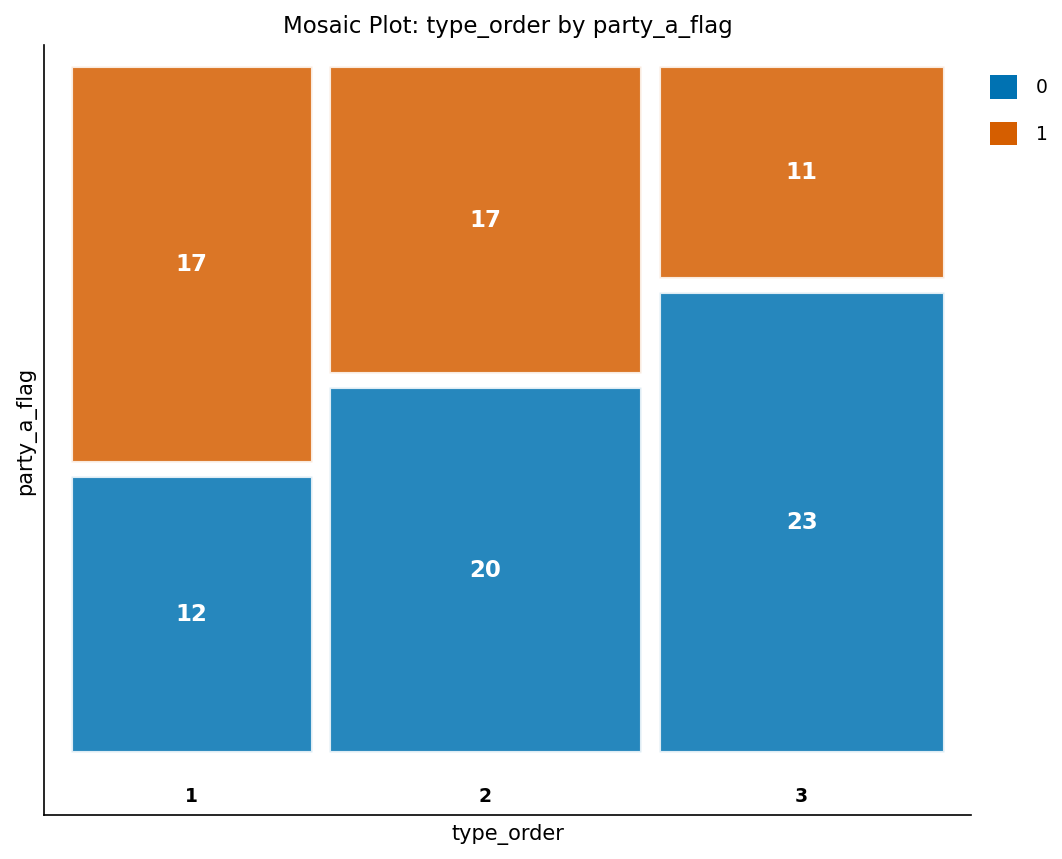

In [5]:
/* --------------------------------------------------------
   Cochran-Armitage trend test. Recode precinct type to an
   ordinal score (1=Urban, 2=Suburban, 3=Rural) and test
   whether Party A support shows a monotonic trend across
   the gradient. EXACT TREND requests the exact p-value,
   appropriate given the small cell counts.
   -------------------------------------------------------- */
データ work.precinct_ordinal;
    設定 work.precinct_votes;
    /* 順序コード化: 1=都市部, 2=郊外, 3=農村部 */
    もし precinct_type = '都市部' なら type_order = 1;
    他 もし precinct_type = '郊外' なら type_order = 2;
    他 type_order = 3;
    /* 二値アウトカム: 政党A対それ以外の政党 */
    party_a_flag = (party = '政党A');
実行;

処理 度数 データ=work.precinct_ordinal;
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    見出 type_order = "地区順序 (1=都市部,2=郊外,3=農村部)" party_a_flag = "政党A支持フラグ";
    表題 'コクラン・アーミテージ傾向検定：地区勾配に沿った政党A支持';
実行;


                                                       郡内の地区タイプ分布                                                       

                                                   The FREQ Procedure

Table of 郡名 by 地区タイプ

郡名                       |       農村部 |        郊外 |       都市部 |      Total
-------------------------+-----------+-----------+-----------+-----------
アダムズ郡                    |         5 |        10 |         4 |         19
                         |      5.00 |     10.00 |      4.00 |      19.00
                         |     26.32 |     52.63 |     21.05 |     100.00
                         |     14.71 |     27.03 |     13.79 |      19.00
-------------------------+-----------+-----------+-----------+-----------
ジェファーソン郡                 |         4 |         7 |         7 |         18
                         |      4.00 |      7.00 |      7.00 |      18.00
                         |     22.22 |     38.89 |     38.89 |     100.00
                         |     11.76 |     18


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


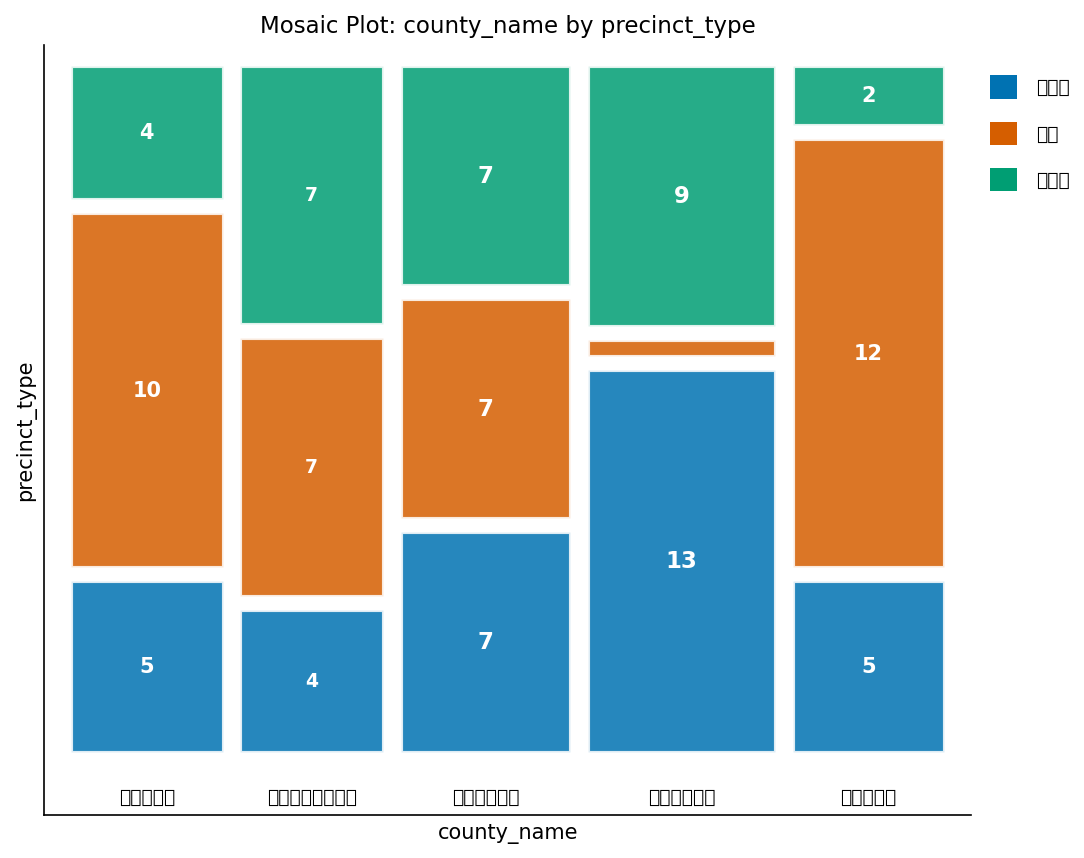

In [6]:
/* --------------------------------------------------------
   County-level view: how the urban/suburban/rural mix
   varies across the five counties. This contextualizes the
   trend result -- the precinct gradient is present in every
   county, but its composition differs.
   -------------------------------------------------------- */
処理 度数 データ=work.precinct_votes;
    TABLES county_name * precinct_type / nocum;
    見出 county_name = "郡名" precinct_type = "地区タイプ";
    表題 '郡内の地区タイプ分布';
実行;


---

### 解釈

100地区全体で、政党Aが全体の最多得票政党であり（45地区）、政党B（34）、政党C（12）、無所属（9）が続く。クロス集計は、政党Aのシェアが都市部から農村部への明確な勾配に従うことを示している：都市部地区の58.6%、郊外地区の46.0%、農村部地区の32.4%を占める一方、政党Bは逆方向に動き、都市部の31.0%から農村部の44.1%まで上昇する。

一般連関の包括的なピアソンのカイ二乗検定は統計的に有意では**ない**（カイ二乗 = 6.78、自由度6、p = 0.3418；クラメールのV = 0.18）。この結果もまた脆弱である：期待度数の表示は5未満のセルがいくつかあることを明らかにしている——例えば無所属の列は期待度数が3.06、3.33、2.61であり、都市部の無所属はわずか1地区しかない——そのため大標本のカイ二乗近似はここでは信頼できない。

コクラン・アーミテージ傾向検定は、都市部・郊外・農村部の順序スコアリングを用いて問いを鋭くする。これは包括的検定が見逃す政党A支持の単調な減少を検出する：傾向カイ二乗 = 4.38、漸近的Pr > ChiSq = 0.0363、**正確Pr >= |Z| = 0.0431**であり、0.05水準で有意である。これがこの分析上の成果である——焦点を絞った正確な単一自由度検定が、疎なセルによって弱められた一般的な6自由度の連関検定では検出できない実際の方向性のあるシグナルを回復する。

郡レベルの視点は、都市部・郊外・農村部の分割が5つの郡すべてに存在することを確認するが、その構成比は郡ごとに異なる：マディソン郡が最も農村部に偏っており（23地区中13地区が農村部）、モンロー郡が最も郊外的である（19地区中12地区）。区割り変更の影響評価にとっての要点は、地区を都市部・農村部軸に沿って移動させる境界変更が政党構成を測定可能な形で変化させること、そしてこの地理的傾向は包括的なカイ二乗検定よりも正確傾向検定によって最もよく裏付けられるということである。


---

                                                       郡内の地区タイプ分布                                                       

                                                   The FREQ Procedure

Table of 地区タイプ by 政党

地区タイプ           |       政党A |       政党B |       政党C |       無所属 |      Total
----------------+-----------+-----------+-----------+-----------+-----------
農村部             |        11 |        15 |         5 |         3 |         34
                |     11.00 |     15.00 |      5.00 |      3.00 |      34.00
                |     32.35 |     44.12 |     14.71 |      8.82 |     100.00
                |     24.44 |     44.12 |     41.67 |     33.33 |      34.00
----------------+-----------+-----------+-----------+-----------+-----------
郊外              |        17 |        10 |         5 |         5 |         37
                |     17.00 |     10.00 |      5.00 |      5.00 |      37.00
                |     45.95 |     27.03 |     13.51 |     13.51 |     100.00
               


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


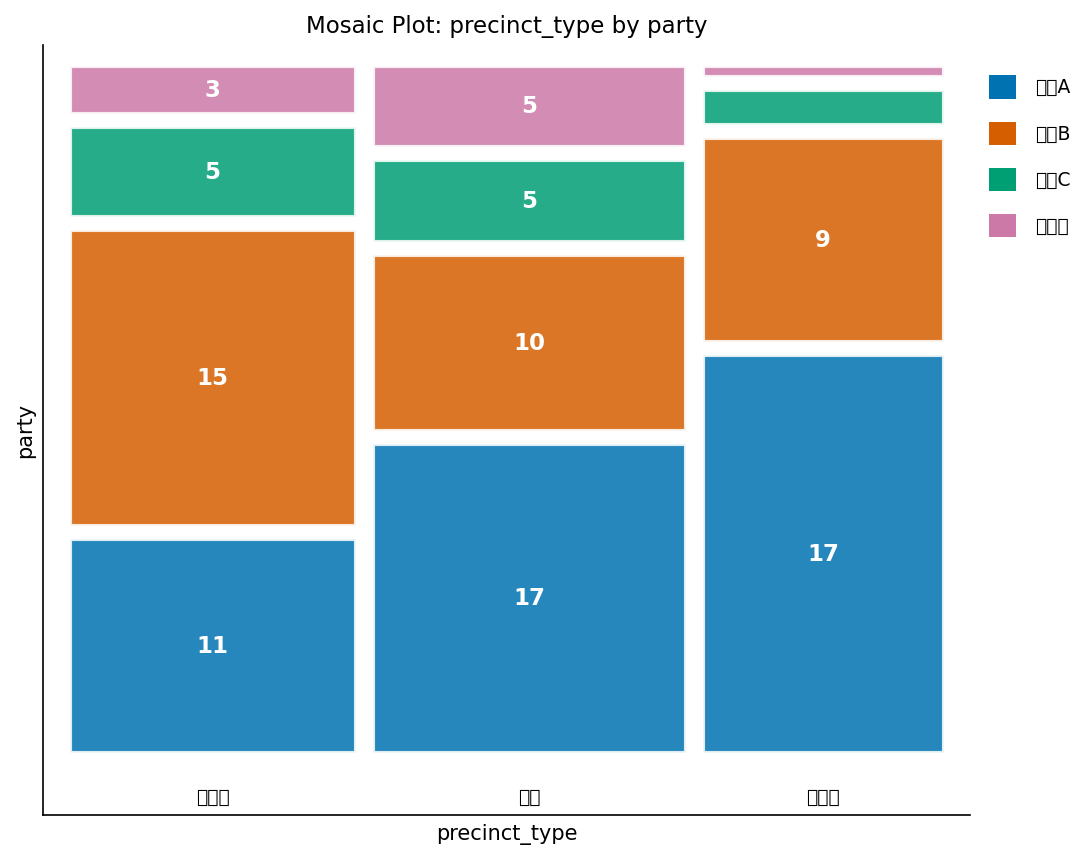

In [7]:
/* --------------------------------------------------------
   Export the precinct type x party summary for downstream
   redistricting impact assessment.
   -------------------------------------------------------- */
処理 度数 データ=work.precinct_votes;
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
    見出 precinct_type = "地区タイプ" party = "政党";
実行;

処理 EXPORT データ=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REPLACE;
実行;


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
提供： <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>